# Trial CLIP untuk Analisis Visual Pariwisata

Notebook ini memakai CLIP zero-shot image classification untuk membaca `dataset/images/1.jpg` dan memilih elemen visual dari daftar 4A pariwisata plus suasana tambahan.

Catatan: CLIP memberi skor kemiripan gambar-teks, bukan bounding box seperti object detection. Jadi hasilnya berupa label visual yang paling relevan terhadap gambar.

## 1. Setup

Jika package belum tersedia, jalankan baris berikut sekali saja:

```python
# %pip install -q torch transformers pillow pandas
```

In [ ]:
from pathlib import Path

import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

IMAGE_PATH = Path("dataset/images/273.jpg")
MODEL_NAME = "openai/clip-vit-base-patch32"

# True = pakai model dari cache lokal dan tidak mencoba akses internet.
# Ubah ke False jika model belum ada dan ingin download otomatis dari Hugging Face.
LOCAL_FILES_ONLY = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Ambang multi-label. Turunkan ke 0.015 jika ingin hasil lebih banyak.
MIN_PROBABILITY = 0.02
MAX_DETECTED_LABELS = 15

print(f"Device: {DEVICE}")
print(f"Image path: {IMAGE_PATH.resolve()}")

Device: cpu
Image path: C:\Users\elsae\.vscode\Documents\city-branding-multimodal\dataset\images\273.jpg


In [53]:
LABELS = [
    # Attraction
    {"category": "Attraction", "label_en": "beach", "label_id": "pantai"},
    {"category": "Attraction", "label_en": "mountain", "label_id": "gunung"},
    {"category": "Attraction", "label_en": "waterfall", "label_id": "air terjun"},
    {"category": "Attraction", "label_en": "lake", "label_id": "danau"},
    {"category": "Attraction", "label_en": "sea", "label_id": "laut"},
    {"category": "Attraction", "label_en": "island", "label_id": "pulau"},
    {"category": "Attraction", "label_en": "forest", "label_id": "hutan"},
    {"category": "Attraction", "label_en": "sunset", "label_id": "matahari terbenam"},
    {"category": "Attraction", "label_en": "sunrise", "label_id": "matahari terbit"},
    {"category": "Attraction", "label_en": "natural landscape", "label_id": "lanskap alam"},
    {"category": "Attraction", "label_en": "tropical scenery", "label_id": "pemandangan tropis"},
    {"category": "Attraction", "label_en": "volcano", "label_id": "gunung berapi"},
    {"category": "Attraction", "label_en": "cliff", "label_id": "tebing"},
    {"category": "Attraction", "label_en": "river", "label_id": "sungai"},
    {"category": "Attraction", "label_en": "cave", "label_id": "gua"},
    {"category": "Attraction", "label_en": "cultural attraction", "label_id": "daya tarik budaya"},
    {"category": "Attraction", "label_en": "traditional house", "label_id": "rumah tradisional"},
    {"category": "Attraction", "label_en": "temple", "label_id": "candi atau pura"},
    {"category": "Attraction", "label_en": "monument", "label_id": "monumen"},
    {"category": "Attraction", "label_en": "historical building", "label_id": "bangunan bersejarah"},
    {"category": "Attraction", "label_en": "scenic view", "label_id": "pemandangan indah"},
    {"category": "Attraction", "label_en": "recreation area", "label_id": "area rekreasi"},
    {"category": "Attraction", "label_en": "camping area", "label_id": "area berkemah"},
    {"category": "Attraction", "label_en": "crowd of tourists", "label_id": "keramaian wisatawan"},
    {"category": "Attraction", "label_en": "outdoor activity", "label_id": "aktivitas luar ruangan"},
    {"category": "Attraction", "label_en": "snorkeling", "label_id": "snorkeling"},
    {"category": "Attraction", "label_en": "diving", "label_id": "menyelam"},
    {"category": "Attraction", "label_en": "hiking", "label_id": "mendaki"},
    {"category": "Attraction", "label_en": "beach recreation", "label_id": "rekreasi pantai"},

    # Accessibility
    {"category": "Accessibility", "label_en": "road", "label_id": "jalan"},
    {"category": "Accessibility", "label_en": "highway", "label_id": "jalan raya"},
    {"category": "Accessibility", "label_en": "bridge", "label_id": "jembatan"},
    {"category": "Accessibility", "label_en": "harbor", "label_id": "pelabuhan"},
    {"category": "Accessibility", "label_en": "port", "label_id": "pelabuhan"},
    {"category": "Accessibility", "label_en": "airport", "label_id": "bandara"},
    {"category": "Accessibility", "label_en": "parking area", "label_id": "area parkir"},
    {"category": "Accessibility", "label_en": "transportation", "label_id": "transportasi"},
    {"category": "Accessibility", "label_en": "vehicle", "label_id": "kendaraan"},
    {"category": "Accessibility", "label_en": "motorcycle", "label_id": "motor"},
    {"category": "Accessibility", "label_en": "car", "label_id": "mobil"},
    {"category": "Accessibility", "label_en": "bus", "label_id": "bus"},
    {"category": "Accessibility", "label_en": "boat", "label_id": "perahu"},
    {"category": "Accessibility", "label_en": "ferry", "label_id": "kapal feri"},
    {"category": "Accessibility", "label_en": "traffic sign", "label_id": "rambu lalu lintas"},
    {"category": "Accessibility", "label_en": "pedestrian path", "label_id": "jalur pejalan kaki"},
    {"category": "Accessibility", "label_en": "entrance gate", "label_id": "gerbang masuk"},
    {"category": "Accessibility", "label_en": "tourism access road", "label_id": "jalan akses wisata"},
    {"category": "Accessibility", "label_en": "public transportation", "label_id": "transportasi umum"},
    {"category": "Accessibility", "label_en": "dock", "label_id": "dermaga"},
    {"category": "Accessibility", "label_en": "pathway", "label_id": "jalur"},
    {"category": "Accessibility", "label_en": "stairs", "label_id": "tangga"},
    {"category": "Accessibility", "label_en": "direction sign", "label_id": "papan petunjuk arah"},

    # Amenities
    {"category": "Amenities", "label_en": "hotel", "label_id": "hotel"},
    {"category": "Amenities", "label_en": "resort", "label_id": "resort"},
    {"category": "Amenities", "label_en": "homestay", "label_id": "homestay"},
    {"category": "Amenities", "label_en": "restaurant", "label_id": "restoran"},
    {"category": "Amenities", "label_en": "cafe", "label_id": "kafe"},
    {"category": "Amenities", "label_en": "food stall", "label_id": "warung makan"},
    {"category": "Amenities", "label_en": "public toilet", "label_id": "toilet umum"},
    {"category": "Amenities", "label_en": "mosque", "label_id": "masjid"},
    {"category": "Amenities", "label_en": "prayer room", "label_id": "mushola"},
    {"category": "Amenities", "label_en": "souvenir shop", "label_id": "toko suvenir"},
    {"category": "Amenities", "label_en": "tourism facility", "label_id": "fasilitas wisata"},
    {"category": "Amenities", "label_en": "parking facility", "label_id": "fasilitas parkir"},
    {"category": "Amenities", "label_en": "gazebo", "label_id": "gazebo"},
    {"category": "Amenities", "label_en": "seating area", "label_id": "area duduk"},
    {"category": "Amenities", "label_en": "swimming pool", "label_id": "kolam renang"},
    {"category": "Amenities", "label_en": "playground", "label_id": "taman bermain"},
    {"category": "Amenities", "label_en": "camping facility", "label_id": "fasilitas berkemah"},
    {"category": "Amenities", "label_en": "market", "label_id": "pasar"},
    {"category": "Amenities", "label_en": "information board", "label_id": "papan informasi"},
    {"category": "Amenities", "label_en": "street lighting", "label_id": "lampu jalan"},
    {"category": "Amenities", "label_en": "wifi area", "label_id": "area wifi"},
    {"category": "Amenities", "label_en": "resting area", "label_id": "area istirahat"},

    # Ancillary
    {"category": "Ancillary", "label_en": "tourism event", "label_id": "acara wisata"},
    {"category": "Ancillary", "label_en": "festival", "label_id": "festival"},
    {"category": "Ancillary", "label_en": "cultural performance", "label_id": "pertunjukan budaya"},
    {"category": "Ancillary", "label_en": "tour guide", "label_id": "pemandu wisata"},
    {"category": "Ancillary", "label_en": "tourism office", "label_id": "kantor pariwisata"},
    {"category": "Ancillary", "label_en": "tourism information center", "label_id": "pusat informasi wisata"},
    {"category": "Ancillary", "label_en": "community activity", "label_id": "aktivitas komunitas"},
    {"category": "Ancillary", "label_en": "local guide", "label_id": "pemandu lokal"},
    {"category": "Ancillary", "label_en": "tourism promotion banner", "label_id": "spanduk promosi wisata"},
    {"category": "Ancillary", "label_en": "tourism organization", "label_id": "organisasi pariwisata"},
    {"category": "Ancillary", "label_en": "security officer", "label_id": "petugas keamanan"},
    {"category": "Ancillary", "label_en": "rescue team", "label_id": "tim penyelamat"},
    {"category": "Ancillary", "label_en": "volunteers", "label_id": "relawan"},
    {"category": "Ancillary", "label_en": "government tourism activity", "label_id": "aktivitas pariwisata pemerintah"},
    {"category": "Ancillary", "label_en": "exhibition", "label_id": "pameran"},
    {"category": "Ancillary", "label_en": "tourism campaign", "label_id": "kampanye pariwisata"},
    {"category": "Ancillary", "label_en": "official tourism signage", "label_id": "papan resmi pariwisata"},
    {"category": "Ancillary", "label_en": "ticket counter", "label_id": "loket tiket"},
    {"category": "Ancillary", "label_en": "tourism management activity", "label_id": "aktivitas pengelolaan wisata"},

    # Scene / Suasana Tambahan
    {"category": "Scene", "label_en": "crowded tourism area", "label_id": "area wisata ramai"},
    {"category": "Scene", "label_en": "quiet place", "label_id": "tempat tenang"},
    {"category": "Scene", "label_en": "relaxing atmosphere", "label_id": "suasana santai"},
    {"category": "Scene", "label_en": "adventure tourism", "label_id": "wisata petualangan"},
    {"category": "Scene", "label_en": "family tourism", "label_id": "wisata keluarga"},
    {"category": "Scene", "label_en": "romantic scenery", "label_id": "pemandangan romantis"},
    {"category": "Scene", "label_en": "urban tourism", "label_id": "wisata perkotaan"},
    {"category": "Scene", "label_en": "rural tourism", "label_id": "wisata pedesaan"},
    {"category": "Scene", "label_en": "eco tourism", "label_id": "ekowisata"},
    {"category": "Scene", "label_en": "marine tourism", "label_id": "wisata bahari"},
    {"category": "Scene", "label_en": "nature tourism", "label_id": "wisata alam"},
    {"category": "Scene", "label_en": "cultural tourism", "label_id": "wisata budaya"},
    {"category": "Scene", "label_en": "night tourism", "label_id": "wisata malam"},
    {"category": "Scene", "label_en": "cloudy sky", "label_id": "langit berawan"},
    {"category": "Scene", "label_en": "sunny weather", "label_id": "cuaca cerah"},
    {"category": "Scene", "label_en": "tropical environment", "label_id": "lingkungan tropis"},
    {"category": "Scene", "label_en": "clean environment", "label_id": "lingkungan bersih"},
    {"category": "Scene", "label_en": "dirty environment", "label_id": "lingkungan kotor"},
    {"category": "Scene", "label_en": "damaged infrastructure", "label_id": "infrastruktur rusak"},
    {"category": "Scene", "label_en": "modern tourism area", "label_id": "area wisata modern"},
    {"category": "Scene", "label_en": "traditional tourism area", "label_id": "area wisata tradisional"},
]

labels_df = pd.DataFrame(LABELS)
print(f"Total label: {len(labels_df)}")
labels_df.groupby("category").size().rename("jumlah_label")

Total label: 114


category
Accessibility    23
Amenities        22
Ancillary        19
Attraction       29
Scene            21
Name: jumlah_label, dtype: int64

In [54]:
try:
    processor = CLIPProcessor.from_pretrained(
        MODEL_NAME,
        local_files_only=LOCAL_FILES_ONLY,
        use_fast=False,
    )
    model = CLIPModel.from_pretrained(
        MODEL_NAME,
        local_files_only=LOCAL_FILES_ONLY,
    ).to(DEVICE)
    model.eval()
except OSError as exc:
    raise RuntimeError(
        "Model CLIP belum ada di cache lokal. Jika ingin download otomatis, ubah "
        "LOCAL_FILES_ONLY = False lalu jalankan ulang cell ini dengan koneksi internet."
    ) from exc

print("Model CLIP siap dipakai.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model CLIP siap dipakai.


Ukuran gambar: 1440 x 1440


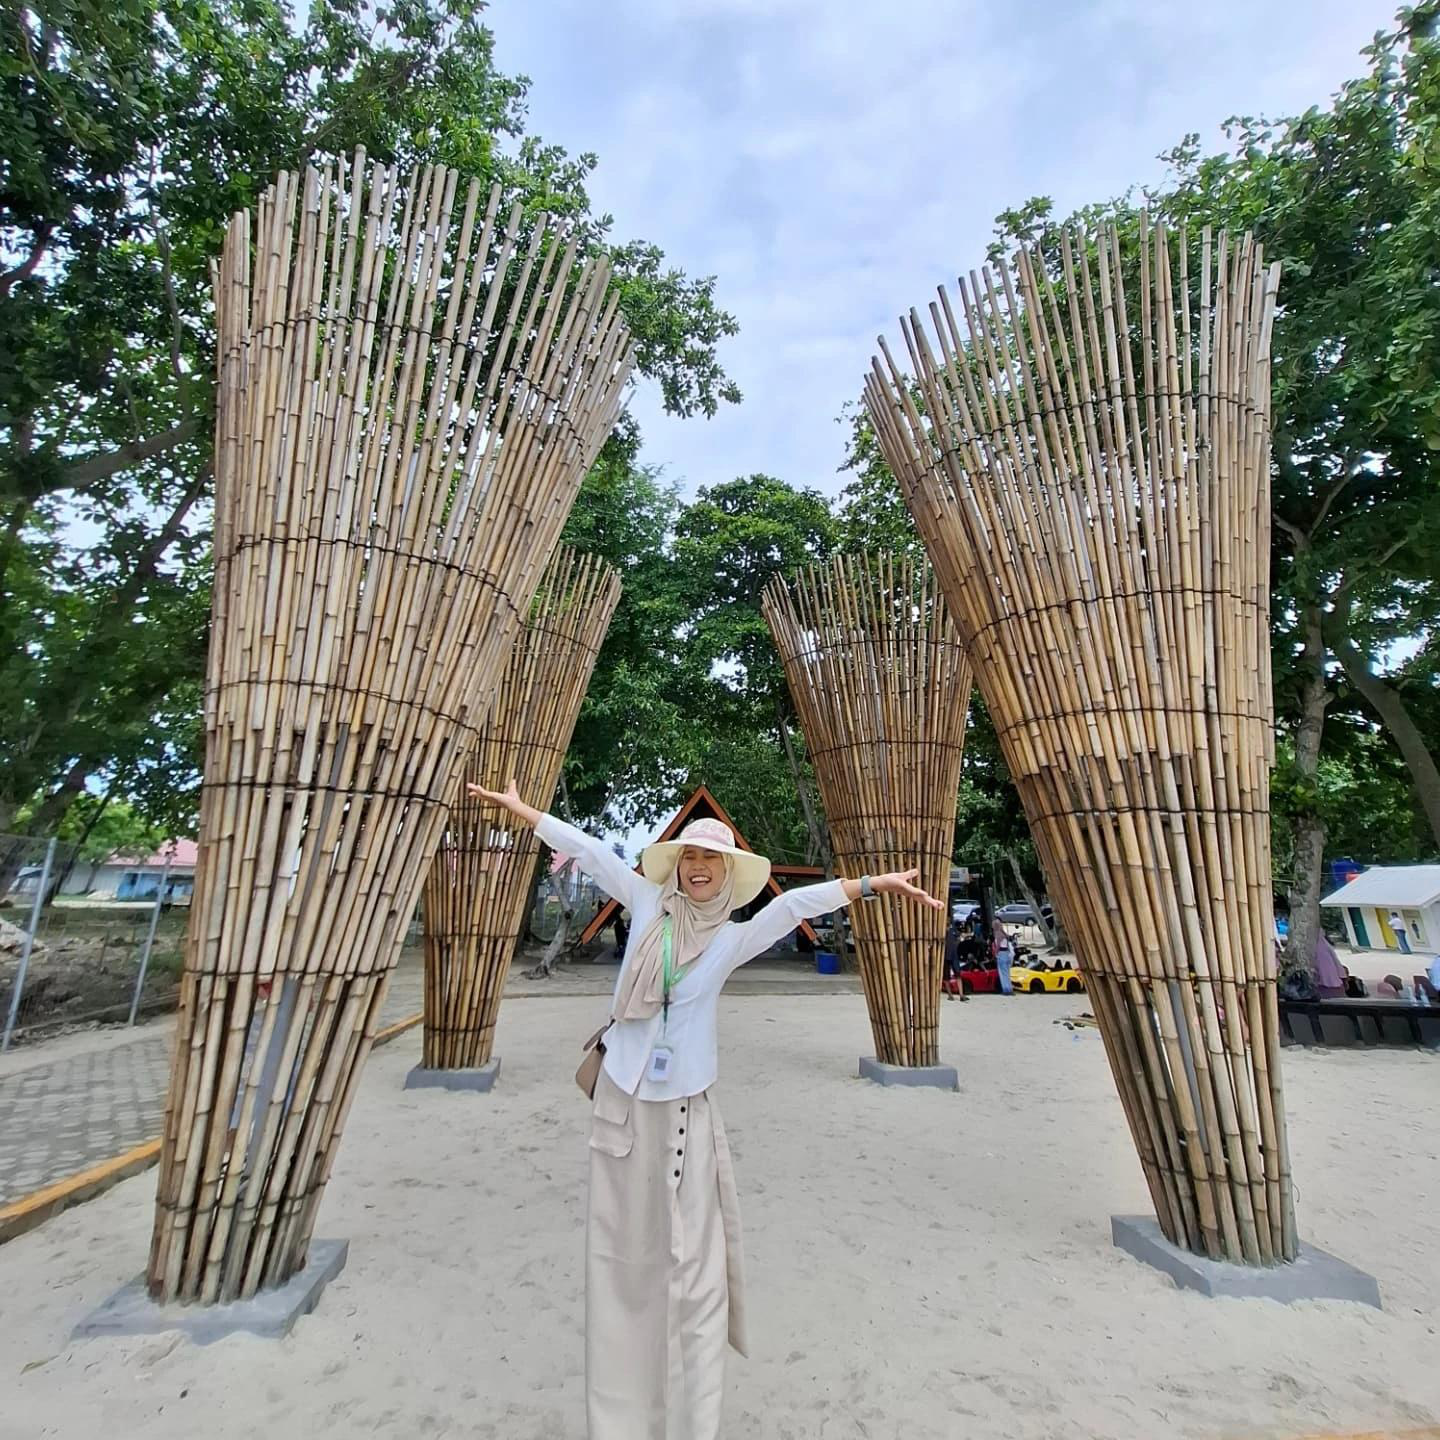

In [55]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH.resolve()}")

image = Image.open(IMAGE_PATH).convert("RGB")
print(f"Ukuran gambar: {image.size[0]} x {image.size[1]}")
display(image)

In [56]:
PROMPT_TEMPLATES = [
    "a photo of {label}",
    "a tourism photo showing {label}",
    "a travel destination with {label}",
    "an Instagram travel photo of {label}",
]


def make_prompts(label_en: str) -> list[str]:
    return [template.format(label=label_en) for template in PROMPT_TEMPLATES]


def get_logits_per_image(outputs) -> torch.Tensor:
    if hasattr(outputs, "logits_per_image"):
        return outputs.logits_per_image
    if isinstance(outputs, dict) and "logits_per_image" in outputs:
        return outputs["logits_per_image"]
    if isinstance(outputs, (tuple, list)):
        return outputs[0]
    raise TypeError(f"Output CLIP tidak memiliki logits_per_image: {type(outputs)}")


@torch.no_grad()
def analyze_image_with_clip(image_path: Path, label_items: list[dict]) -> pd.DataFrame:
    image = Image.open(image_path).convert("RGB")
    prompts = [prompt for item in label_items for prompt in make_prompts(item["label_en"])]

    inputs = processor(
        text=prompts,
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)
    outputs = model(**inputs)

    prompt_logits = get_logits_per_image(outputs).squeeze(0)
    logits = prompt_logits.reshape(len(label_items), len(PROMPT_TEMPLATES)).mean(dim=1)
    probabilities = logits.softmax(dim=0)

    result = pd.DataFrame(label_items).copy()
    result["similarity_logit"] = logits.detach().cpu().numpy()
    result["probability"] = probabilities.detach().cpu().numpy()
    result = result.sort_values("probability", ascending=False).reset_index(drop=True)
    result.insert(0, "rank", range(1, len(result) + 1))
    return result


def pick_detected_labels(result: pd.DataFrame, min_probability: float, max_labels: int) -> pd.DataFrame:
    detected = result[result["probability"] >= min_probability].head(max_labels)

    # Fallback: kalau threshold terlalu ketat, tetap tampilkan label teratas.
    if detected.empty:
        detected = result.head(min(5, max_labels))

    return detected[["rank", "category", "label_en", "label_id", "probability", "similarity_logit"]]


def top_labels_per_category(result: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    return (
        result.groupby("category", group_keys=False)
        .head(top_n)[["rank", "category", "label_en", "label_id", "probability", "similarity_logit"]]
        .reset_index(drop=True)
    )

In [57]:
results = analyze_image_with_clip(IMAGE_PATH, LABELS)
detected = pick_detected_labels(results, MIN_PROBABILITY, MAX_DETECTED_LABELS)

print("Label visual yang terdeteksi dari gambar:")
display(detected.style.format({"probability": "{:.2%}", "similarity_logit": "{:.2f}"}))

Label visual yang terdeteksi dari gambar:


,rank,category,label_en,label_id,probability,similarity_logit
0,1,Scene,eco tourism,ekowisata,11.19%,27.04
1,2,Ancillary,cultural performance,pertunjukan budaya,6.63%,26.51
2,3,Scene,cultural tourism,wisata budaya,6.53%,26.50
3,4,Attraction,cultural attraction,daya tarik budaya,4.85%,26.20
4,5,Scene,traditional tourism area,area wisata tradisional,4.64%,26.16
5,6,Ancillary,tourism event,acara wisata,3.54%,25.88
6,7,Ancillary,tourism campaign,kampanye pariwisata,3.41%,25.85
7,8,Ancillary,local guide,pemandu lokal,3.21%,25.79
8,9,Ancillary,tourism management activity,aktivitas pengelolaan wisata,2.83%,25.66
9,10,Ancillary,official tourism signage,papan resmi pariwisata,2.80%,25.65


In [58]:
print("Top label per kategori:")
category_summary = top_labels_per_category(results, top_n=5)
display(category_summary.style.format({"probability": "{:.2%}", "similarity_logit": "{:.2f}"}))

Top label per kategori:


,rank,category,label_en,label_id,probability,similarity_logit
0,1,Scene,eco tourism,ekowisata,11.19%,27.04
1,2,Ancillary,cultural performance,pertunjukan budaya,6.63%,26.51
2,3,Scene,cultural tourism,wisata budaya,6.53%,26.50
3,4,Attraction,cultural attraction,daya tarik budaya,4.85%,26.20
4,5,Scene,traditional tourism area,area wisata tradisional,4.64%,26.16
5,6,Ancillary,tourism event,acara wisata,3.54%,25.88
6,7,Ancillary,tourism campaign,kampanye pariwisata,3.41%,25.85
7,8,Ancillary,local guide,pemandu lokal,3.21%,25.79
8,9,Ancillary,tourism management activity,aktivitas pengelolaan wisata,2.83%,25.66
9,11,Accessibility,entrance gate,gerbang masuk,2.70%,25.61


In [59]:
summary_text = ", ".join(
    f"{row.label_en} ({row.category}, {row.probability:.2%})"
    for row in detected.itertuples(index=False)
)

print("Kesimpulan label terdeteksi:")
print(summary_text)

Kesimpulan label terdeteksi:
eco tourism (Scene, 11.19%), cultural performance (Ancillary, 6.63%), cultural tourism (Scene, 6.53%), cultural attraction (Attraction, 4.85%), traditional tourism area (Scene, 4.64%), tourism event (Ancillary, 3.54%), tourism campaign (Ancillary, 3.41%), local guide (Ancillary, 3.21%), tourism management activity (Ancillary, 2.83%), official tourism signage (Ancillary, 2.80%), entrance gate (Accessibility, 2.70%), festival (Ancillary, 2.69%), outdoor activity (Attraction, 2.66%), modern tourism area (Scene, 2.56%), community activity (Ancillary, 2.46%)


In [60]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

detected_output_path = OUTPUT_DIR / "clip_detected_1.csv"
all_scores_output_path = OUTPUT_DIR / "clip_all_scores_1.csv"

detected.to_csv(detected_output_path, index=False)
results.to_csv(all_scores_output_path, index=False)

print(f"Hasil label terdeteksi disimpan ke: {detected_output_path}")
print(f"Semua skor label disimpan ke: {all_scores_output_path}")

Hasil label terdeteksi disimpan ke: outputs\clip_detected_1.csv
Semua skor label disimpan ke: outputs\clip_all_scores_1.csv
